# CSCN8020 Assignment 2
## Taxi Gymnasium Environment with Tabular Q-Learning

**Student:** Emmanuel Ihejiamaizu  
**Student ID:** 9080005  
**Course:** CSCN8020 – Reinforcement Learning Programming  

---

### Project purpose
This notebook implements, trains, evaluates, and analyzes a **tabular Q-learning agent** in Gymnasium's `Taxi-v3` environment. The agent learns how to move a taxi, pick up a passenger, and deliver the passenger to the correct destination while avoiding unnecessary movement and illegal pickup or drop-off actions.

The notebook is designed as a reproducible mini-project rather than a collection of disconnected cells. It uses object-oriented classes to separate environment handling, Q-learning behaviour, training, metric collection, plotting, logging, and experiment orchestration.

## 1. Taxi environment overview

`Taxi-v3` is a 5 × 5 grid-world. A taxi must navigate to a passenger, pick the passenger up, travel to the passenger's destination, and then complete a legal drop-off.

### Action space: `Discrete(6)`
The action space contains exactly six integer-coded actions:

| Action ID | Meaning |
|---:|---|
| 0 | Move south |
| 1 | Move north |
| 2 | Move east |
| 3 | Move west |
| 4 | Pick up passenger |
| 5 | Drop off passenger |

### Observation space: `Discrete(500)`
The environment represents each state as one integer from 0 to 499. The 500 states come from:

- 25 possible taxi positions on the 5 × 5 grid,
- 5 passenger locations: Red, Green, Yellow, Blue, or already in the taxi,
- 4 possible destination locations: Red, Green, Yellow, or Blue.

Therefore: `25 × 5 × 4 = 500` states.

The scalar observation is encoded as:

\[
((taxi\_row \times 5 + taxi\_col) \times 5 + passenger\_location) \times 4 + destination
\]

### Reward structure

| Event | Reward |
|---|---:|
| Ordinary movement step | -1 |
| Successful passenger delivery | +20 |
| Illegal pickup or drop-off | -10 |

The reward function makes efficient delivery desirable and makes wasted movement or illegal actions expensive.

## 2. Q-learning theory

Q-learning is a **model-free, off-policy, temporal-difference (TD) reinforcement learning algorithm**. It learns an action-value function, \(Q(s,a)\), which estimates the expected discounted future reward for taking action \(a\) in state \(s\) and then behaving optimally afterward.

The update rule is:

\[
Q(S,A) \leftarrow Q(S,A) + \alpha\left[R + \gamma \max_a Q(S',a) - Q(S,A)\right]
\]

Where:

- \(S\): current state
- \(A\): selected action
- \(R\): observed reward
- \(S'\): next state
- \(\alpha\): learning rate
- \(\gamma\): discount factor
- \(\max_a Q(S',a)\): best estimated value available from the next state

The agent explores using an \(\epsilon\)-greedy behaviour policy. With probability \(\epsilon\), it chooses a random action. With probability \(1-\epsilon\), it chooses the action with the largest current Q-value. However, the update target always uses the greedy future value, so Q-learning is off-policy.

## 3. Mapping this notebook to Sutton and Barto-style Q-learning pseudocode

| Pseudocode idea | Notebook implementation |
|---|---|
| Initialize \(Q(s,a)\) arbitrarily | `QLearningAgent` creates a zero-filled Q-table of shape `(500, 6)` |
| Initialize state \(S\) | `env.reset()` returns the current encoded Taxi state |
| Choose action \(A\) from \(S\) using an \(\epsilon\)-greedy policy | `agent.select_action(state, explore=True)` |
| Take action \(A\), observe \(R, S'\) | `env.step(action)` |
| Update Q-value | `agent.update(...)` applies the TD equation |
| Set \(S \leftarrow S'\) | `state = next_state` |
| Repeat until terminal state | training loop stops on `terminated` or `truncated` |

A `truncated` episode occurs when the environment's time limit is reached. For this assignment, both terminal and truncated endings are treated as the end of the current update trajectory, so the agent does not bootstrap beyond the episode boundary.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any
import logging
import random

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Reproducibility settings
SEED = 8020
np.random.seed(SEED)
random.seed(SEED)

# Assignment-required baseline hyperparameters
BASELINE_ALPHA = 0.1
BASELINE_EPSILON = 0.1
GAMMA = 0.9

# Experiment settings. Keeping all runs at the same episode count supports fair comparison.
TRAINING_EPISODES = 2000
EVALUATION_EPISODES = 100
MAX_EPISODE_STEPS = 200
ROLLING_WINDOW = 100

PROJECT_ROOT = Path.cwd()
ASSETS_DIR = PROJECT_ROOT / "assets" / "plots"
LOG_DIR = PROJECT_ROOT / "logs"
RESULTS_DIR = PROJECT_ROOT / "results"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print("Setup complete.")

Project root: /mnt/data/CSCN8020_Assignment2_Final
Setup complete.


## 4. Object-oriented architecture

The implementation below intentionally separates responsibilities:

- `TaxiEnvironmentManager`: creates and describes the Gymnasium environment.
- `QLearningAgent`: owns the Q-table, epsilon-greedy action selection, and TD updates.
- `MetricsCollector`: stores training metrics for each episode.
- `ExperimentLogger`: writes a readable execution log file.
- `QLearningTrainer`: runs the training and greedy evaluation loops.
- `PlotManager`: produces and saves plots.
- `ExperimentRunner`: runs the required baseline, isolated hyperparameter experiments, and final best-combination experiment.

In [2]:
class TaxiEnvironmentManager:
    """Creates Taxi-v3 environments and provides readable state/action descriptions."""

    ACTION_NAMES = {
        0: "Move south",
        1: "Move north",
        2: "Move east",
        3: "Move west",
        4: "Pick up passenger",
        5: "Drop off passenger",
    }
    PASSENGER_LOCATIONS = {
        0: "Red",
        1: "Green",
        2: "Yellow",
        3: "Blue",
        4: "In taxi",
    }
    DESTINATIONS = {
        0: "Red",
        1: "Green",
        2: "Yellow",
        3: "Blue",
    }

    def __init__(self, env_id: str = "Taxi-v3", max_episode_steps: int = MAX_EPISODE_STEPS):
        self.env_id = env_id
        self.max_episode_steps = max_episode_steps

    def create(self) -> gym.Env:
        return gym.make(self.env_id, max_episode_steps=self.max_episode_steps)

    def inspect_spaces(self) -> dict[str, int]:
        env = self.create()
        details = {
            "number_of_states": int(env.observation_space.n),
            "number_of_actions": int(env.action_space.n),
        }
        env.close()
        return details

    def decode_state(self, state: int) -> dict[str, Any]:
        """Decode Taxi's scalar observation into its state components."""
        env = self.create()
        taxi_row, taxi_col, passenger_location, destination = env.unwrapped.decode(int(state))
        env.close()
        return {
            "state_id": int(state),
            "taxi_row": int(taxi_row),
            "taxi_col": int(taxi_col),
            "passenger_location": self.PASSENGER_LOCATIONS[int(passenger_location)],
            "destination": self.DESTINATIONS[int(destination)],
        }


class QLearningAgent:
    """Tabular Q-learning agent with epsilon-greedy exploration."""

    def __init__(
        self,
        num_states: int,
        num_actions: int,
        alpha: float,
        gamma: float,
        epsilon: float,
        seed: int,
    ) -> None:
        self.num_states = num_states
        self.num_actions = num_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.rng = np.random.default_rng(seed)
        self.q_table = np.zeros((num_states, num_actions), dtype=np.float64)

    def select_action(self, state: int, explore: bool = True) -> int:
        """Choose an action using epsilon-greedy behaviour, or greedily during evaluation."""
        if explore and self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.num_actions))
        return int(np.argmax(self.q_table[state]))

    def update(
        self,
        state: int,
        action: int,
        reward: float,
        next_state: int,
        episode_end: bool,
    ) -> tuple[float, float]:
        """Apply the Q-learning TD update and return the TD target and TD error."""
        current_q = self.q_table[state, action]
        best_next_q = 0.0 if episode_end else float(np.max(self.q_table[next_state]))
        td_target = reward + self.gamma * best_next_q
        td_error = td_target - current_q
        self.q_table[state, action] += self.alpha * td_error
        return float(td_target), float(td_error)


class MetricsCollector:
    """Stores per-episode training metrics and creates summary statistics."""

    def __init__(self) -> None:
        self.returns: list[float] = []
        self.steps: list[int] = []
        self.successes: list[int] = []
        self.illegal_actions: list[int] = []
        self.truncated_episodes: list[int] = []

    def record_episode(
        self,
        episode_return: float,
        steps: int,
        success: bool,
        illegal_actions: int,
        truncated: bool,
    ) -> None:
        self.returns.append(float(episode_return))
        self.steps.append(int(steps))
        self.successes.append(int(success))
        self.illegal_actions.append(int(illegal_actions))
        self.truncated_episodes.append(int(truncated))

    def to_frame(self, rolling_window: int = ROLLING_WINDOW) -> pd.DataFrame:
        frame = pd.DataFrame(
            {
                "episode": np.arange(1, len(self.returns) + 1),
                "return": self.returns,
                "steps": self.steps,
                "success": self.successes,
                "illegal_actions": self.illegal_actions,
                "truncated": self.truncated_episodes,
            }
        )
        frame["moving_average_return"] = frame["return"].rolling(rolling_window, min_periods=1).mean()
        frame["moving_average_steps"] = frame["steps"].rolling(rolling_window, min_periods=1).mean()
        frame["moving_success_rate"] = frame["success"].rolling(rolling_window, min_periods=1).mean()
        return frame

    def summary(self, final_window: int = 500) -> dict[str, float]:
        frame = self.to_frame()
        tail = frame.tail(min(final_window, len(frame)))
        return {
            "training_mean_return_last_window": float(tail["return"].mean()),
            "training_mean_steps_last_window": float(tail["steps"].mean()),
            "training_success_rate_last_window": float(tail["success"].mean()),
            "training_mean_illegal_actions_last_window": float(tail["illegal_actions"].mean()),
            "training_truncation_rate_last_window": float(tail["truncated"].mean()),
        }


class ExperimentLogger:
    """Creates a useful assignment log without logging every environment step."""

    def __init__(self, log_path: Path) -> None:
        self.log_path = log_path
        self.log_path.parent.mkdir(parents=True, exist_ok=True)
        self.logger = logging.getLogger("cscn8020_assignment2")
        self.logger.setLevel(logging.INFO)
        self.logger.handlers.clear()
        handler = logging.FileHandler(self.log_path, mode="w", encoding="utf-8")
        handler.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
        self.logger.addHandler(handler)
        self.logger.propagate = False
        self.logger.info("Assignment 2 Q-learning execution started.")

    def start_experiment(self, name: str, alpha: float, epsilon: float, gamma: float, episodes: int) -> None:
        self.logger.info(
            "START | experiment=%s | alpha=%.3f | epsilon=%.3f | gamma=%.3f | episodes=%d",
            name,
            alpha,
            epsilon,
            gamma,
            episodes,
        )

    def progress(self, name: str, episode: int, mean_return: float, mean_steps: float, success_rate: float) -> None:
        self.logger.info(
            "PROGRESS | experiment=%s | episode=%d | recent_mean_return=%.3f | recent_mean_steps=%.3f | recent_success_rate=%.3f",
            name,
            episode,
            mean_return,
            mean_steps,
            success_rate,
        )

    def finish_experiment(self, name: str, metrics: dict[str, float]) -> None:
        self.logger.info("FINISH | experiment=%s | metrics=%s", name, metrics)

    def warning(self, message: str) -> None:
        self.logger.warning(message)


@dataclass
class ExperimentResult:
    name: str
    alpha: float
    epsilon: float
    gamma: float
    agent: QLearningAgent
    training_metrics: pd.DataFrame
    training_summary: dict[str, float]
    evaluation_summary: dict[str, float]


class QLearningTrainer:
    """Runs training and evaluation episodes while keeping the agent and metrics separate."""

    def __init__(self, environment_manager: TaxiEnvironmentManager, experiment_logger: ExperimentLogger) -> None:
        self.environment_manager = environment_manager
        self.experiment_logger = experiment_logger

    def train(
        self,
        name: str,
        alpha: float,
        epsilon: float,
        gamma: float,
        episodes: int,
        seed: int,
        progress_interval: int = 500,
    ) -> ExperimentResult:
        env = self.environment_manager.create()
        agent = QLearningAgent(
            num_states=int(env.observation_space.n),
            num_actions=int(env.action_space.n),
            alpha=alpha,
            gamma=gamma,
            epsilon=epsilon,
            seed=seed,
        )
        metrics = MetricsCollector()
        self.experiment_logger.start_experiment(name, alpha, epsilon, gamma, episodes)

        try:
            for episode in range(1, episodes + 1):
                state, _ = env.reset(seed=seed if episode == 1 else None)
                episode_return = 0.0
                illegal_actions = 0
                terminated = False
                truncated = False

                for step in range(1, self.environment_manager.max_episode_steps + 1):
                    action = agent.select_action(state, explore=True)
                    next_state, reward, terminated, truncated, _ = env.step(action)
                    episode_end = bool(terminated or truncated)
                    agent.update(state, action, reward, next_state, episode_end)

                    episode_return += float(reward)
                    if reward == -10:
                        illegal_actions += 1
                    state = next_state

                    if episode_end:
                        break

                success = bool(terminated and reward == 20)
                metrics.record_episode(
                    episode_return=episode_return,
                    steps=step,
                    success=success,
                    illegal_actions=illegal_actions,
                    truncated=bool(truncated),
                )

                if episode % progress_interval == 0 or episode == episodes:
                    recent = metrics.to_frame().tail(progress_interval)
                    self.experiment_logger.progress(
                        name=name,
                        episode=episode,
                        mean_return=float(recent["return"].mean()),
                        mean_steps=float(recent["steps"].mean()),
                        success_rate=float(recent["success"].mean()),
                    )

            training_frame = metrics.to_frame()
            training_summary = metrics.summary()
            evaluation_summary = self.evaluate(agent, episodes=EVALUATION_EPISODES, seed=seed + 10000)
            combined_metrics = {**training_summary, **evaluation_summary}
            self.experiment_logger.finish_experiment(name, combined_metrics)
            return ExperimentResult(
                name=name,
                alpha=alpha,
                epsilon=epsilon,
                gamma=gamma,
                agent=agent,
                training_metrics=training_frame,
                training_summary=training_summary,
                evaluation_summary=evaluation_summary,
            )
        except Exception as exc:
            self.experiment_logger.warning(f"Experiment '{name}' failed: {exc!r}")
            raise
        finally:
            env.close()

    def evaluate(self, agent: QLearningAgent, episodes: int, seed: int) -> dict[str, float]:
        """Evaluate the learned greedy policy without exploration or further learning."""
        env = self.environment_manager.create()
        returns: list[float] = []
        steps_list: list[int] = []
        successes = 0
        illegal_actions_total = 0

        try:
            for episode in range(episodes):
                state, _ = env.reset(seed=seed if episode == 0 else None)
                episode_return = 0.0
                illegal_actions = 0
                terminated = False
                truncated = False

                for step in range(1, self.environment_manager.max_episode_steps + 1):
                    action = agent.select_action(state, explore=False)
                    next_state, reward, terminated, truncated, _ = env.step(action)
                    episode_return += float(reward)
                    if reward == -10:
                        illegal_actions += 1
                    state = next_state
                    if terminated or truncated:
                        break

                returns.append(episode_return)
                steps_list.append(step)
                illegal_actions_total += illegal_actions
                successes += int(terminated and reward == 20)

            return {
                "evaluation_episodes": float(episodes),
                "evaluation_mean_return": float(np.mean(returns)),
                "evaluation_mean_steps": float(np.mean(steps_list)),
                "evaluation_success_rate": float(successes / episodes),
                "evaluation_mean_illegal_actions": float(illegal_actions_total / episodes),
            }
        finally:
            env.close()


class PlotManager:
    """Creates separate, readable plots and saves them under assets/plots."""

    def __init__(self, output_directory: Path) -> None:
        self.output_directory = output_directory
        self.output_directory.mkdir(parents=True, exist_ok=True)

    def _finish(self, filename: str) -> None:
        plt.tight_layout()
        plt.savefig(self.output_directory / filename, dpi=160, bbox_inches="tight")
        plt.show()
        plt.close()

    def plot_return_per_episode(self, frame: pd.DataFrame, title: str, filename: str) -> None:
        plt.figure(figsize=(10, 4.5))
        plt.plot(frame["episode"], frame["return"], linewidth=0.8)
        plt.title(title)
        plt.xlabel("Episode")
        plt.ylabel("Total reward / return")
        plt.grid(True, alpha=0.3)
        self._finish(filename)

    def plot_steps_per_episode(self, frame: pd.DataFrame, title: str, filename: str) -> None:
        plt.figure(figsize=(10, 4.5))
        plt.plot(frame["episode"], frame["steps"], linewidth=0.8)
        plt.title(title)
        plt.xlabel("Episode")
        plt.ylabel("Steps")
        plt.grid(True, alpha=0.3)
        self._finish(filename)

    def plot_moving_average_return(self, frame: pd.DataFrame, title: str, filename: str) -> None:
        plt.figure(figsize=(10, 4.5))
        plt.plot(frame["episode"], frame["moving_average_return"], linewidth=1.4)
        plt.title(title)
        plt.xlabel("Episode")
        plt.ylabel(f"Moving average return ({ROLLING_WINDOW} episodes)")
        plt.grid(True, alpha=0.3)
        self._finish(filename)

    def plot_experiment_comparison(self, comparison: pd.DataFrame, column: str, title: str, ylabel: str, filename: str) -> None:
        plt.figure(figsize=(11, 4.8))
        plt.bar(comparison["experiment"], comparison[column])
        plt.title(title)
        plt.xlabel("Experiment")
        plt.ylabel(ylabel)
        plt.xticks(rotation=25, ha="right")
        plt.grid(axis="y", alpha=0.3)
        self._finish(filename)


class ExperimentRunner:
    """Runs the required baseline, isolated tests, and best-combination re-run."""

    def __init__(self, trainer: QLearningTrainer, plot_manager: PlotManager) -> None:
        self.trainer = trainer
        self.plot_manager = plot_manager
        self.results: dict[str, ExperimentResult] = {}

    def run_experiment(self, name: str, alpha: float, epsilon: float, gamma: float = GAMMA) -> ExperimentResult:
        result = self.trainer.train(
            name=name,
            alpha=alpha,
            epsilon=epsilon,
            gamma=gamma,
            episodes=TRAINING_EPISODES,
            seed=SEED,
        )
        self.results[name] = result
        return result

    def comparison_table(self, include_best: bool = False) -> pd.DataFrame:
        rows = []
        for name, result in self.results.items():
            if not include_best and name == "Best combination":
                continue
            rows.append(
                {
                    "experiment": name,
                    "alpha": result.alpha,
                    "epsilon": result.epsilon,
                    "gamma": result.gamma,
                    "episodes": len(result.training_metrics),
                    **result.training_summary,
                    **result.evaluation_summary,
                }
            )
        return pd.DataFrame(rows)

    @staticmethod
    def _select_best(frame: pd.DataFrame) -> pd.Series:
        """Prioritize high evaluation return, then high success rate, then fewer evaluation steps."""
        return frame.sort_values(
            by=["evaluation_mean_return", "evaluation_success_rate", "evaluation_mean_steps"],
            ascending=[False, False, True],
        ).iloc[0]

    def run_required_experiments(self) -> tuple[pd.DataFrame, dict[str, float], pd.DataFrame]:
        # Baseline required by the assignment.
        baseline = self.run_experiment("Baseline", BASELINE_ALPHA, BASELINE_EPSILON)

        # Task 3: alter alpha separately while holding epsilon and gamma constant.
        self.run_experiment("Alpha = 0.01", 0.01, BASELINE_EPSILON)
        self.run_experiment("Alpha = 0.001", 0.001, BASELINE_EPSILON)
        self.run_experiment("Alpha = 0.2", 0.2, BASELINE_EPSILON)

        # Task 3: alter epsilon separately while holding alpha and gamma constant.
        self.run_experiment("Epsilon = 0.2", BASELINE_ALPHA, 0.2)
        self.run_experiment("Epsilon = 0.3", BASELINE_ALPHA, 0.3)

        comparison = self.comparison_table(include_best=False)

        # Select best alpha from baseline + alpha-only tests, then best epsilon from baseline + epsilon-only tests.
        alpha_candidates = comparison[comparison["experiment"].isin(["Baseline", "Alpha = 0.01", "Alpha = 0.001", "Alpha = 0.2"])]
        epsilon_candidates = comparison[comparison["experiment"].isin(["Baseline", "Epsilon = 0.2", "Epsilon = 0.3"])]
        best_alpha_row = self._select_best(alpha_candidates)
        best_epsilon_row = self._select_best(epsilon_candidates)
        selected = {"alpha": float(best_alpha_row["alpha"]), "epsilon": float(best_epsilon_row["epsilon"]), "gamma": GAMMA}

        # Task 4: re-run with the best combination selected from measured results.
        self.run_experiment("Best combination", selected["alpha"], selected["epsilon"])
        comparison_with_best = self.comparison_table(include_best=True)

        # Baseline plots required by Task 2.
        self.plot_manager.plot_return_per_episode(
            baseline.training_metrics,
            "Baseline: Total Reward / Return per Episode",
            "baseline_return_per_episode.png",
        )
        self.plot_manager.plot_steps_per_episode(
            baseline.training_metrics,
            "Baseline: Steps Taken per Episode",
            "baseline_steps_per_episode.png",
        )
        self.plot_manager.plot_moving_average_return(
            baseline.training_metrics,
            "Baseline: Average Return over Time",
            "baseline_moving_average_return.png",
        )

        # Compact comparison plots across all experiments.
        self.plot_manager.plot_experiment_comparison(
            comparison_with_best,
            "evaluation_mean_return",
            "Evaluation Mean Return by Experiment",
            "Mean return across greedy evaluation episodes",
            "evaluation_mean_return_comparison.png",
        )
        self.plot_manager.plot_experiment_comparison(
            comparison_with_best,
            "evaluation_mean_steps",
            "Evaluation Mean Steps by Experiment",
            "Mean steps across greedy evaluation episodes",
            "evaluation_mean_steps_comparison.png",
        )
        self.plot_manager.plot_experiment_comparison(
            comparison_with_best,
            "evaluation_success_rate",
            "Evaluation Success Rate by Experiment",
            "Success rate across greedy evaluation episodes",
            "evaluation_success_rate_comparison.png",
        )

        return comparison, selected, comparison_with_best

## 5. Environment inspection and state-decoding helper

Before training, the following cell verifies that the selected Gymnasium environment has the expected 500 states and 6 actions. It also decodes one sample scalar observation into the more meaningful Taxi state components.

In [3]:
environment_manager = TaxiEnvironmentManager()
space_summary = environment_manager.inspect_spaces()
print("Environment space summary:", space_summary)

assert space_summary["number_of_states"] == 500, "Taxi-v3 should provide 500 discrete states."
assert space_summary["number_of_actions"] == 6, "Taxi-v3 should provide 6 discrete actions."

sample_env = environment_manager.create()
sample_state, _ = sample_env.reset(seed=SEED)
sample_env.close()

sample_decoded_state = environment_manager.decode_state(sample_state)
display(pd.DataFrame([sample_decoded_state]))

print("Action mapping:")
for action_id, action_name in TaxiEnvironmentManager.ACTION_NAMES.items():
    print(f"  {action_id}: {action_name}")

Environment space summary: {'number_of_states': 500, 'number_of_actions': 6}


,state_id,taxi_row,taxi_col,passenger_location,destination
0,333,3,1,Blue,Green


Action mapping:
  0: Move south
  1: Move north
  2: Move east
  3: Move west
  4: Pick up passenger
  5: Drop off passenger


## 6. Baseline and hyperparameter experiments

### Baseline
The required starting configuration is:

- learning rate \(\alpha = 0.1\)
- exploration factor \(\epsilon = 0.1\)
- discount factor \(\gamma = 0.9\)

### Controlled hyperparameter tests
The assignment requires changing one parameter at a time.

- Learning-rate tests: `0.01`, `0.001`, and `0.2` while holding \(\epsilon=0.1\) and \(\gamma=0.9\).
- Exploration tests: `0.2` and `0.3` while holding \(\alpha=0.1\) and \(\gamma=0.9\).

Each training run collects episode returns, steps per episode, success information, illegal-action counts, moving averages, and a final 100-episode greedy-policy evaluation.

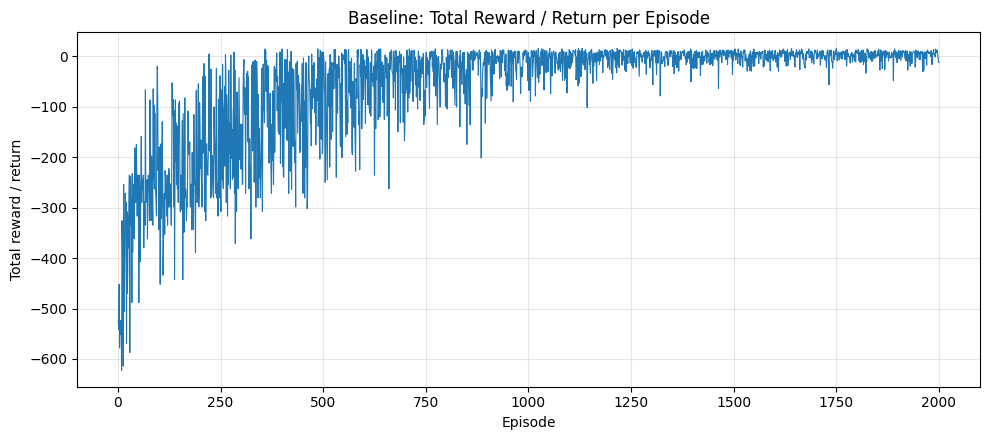

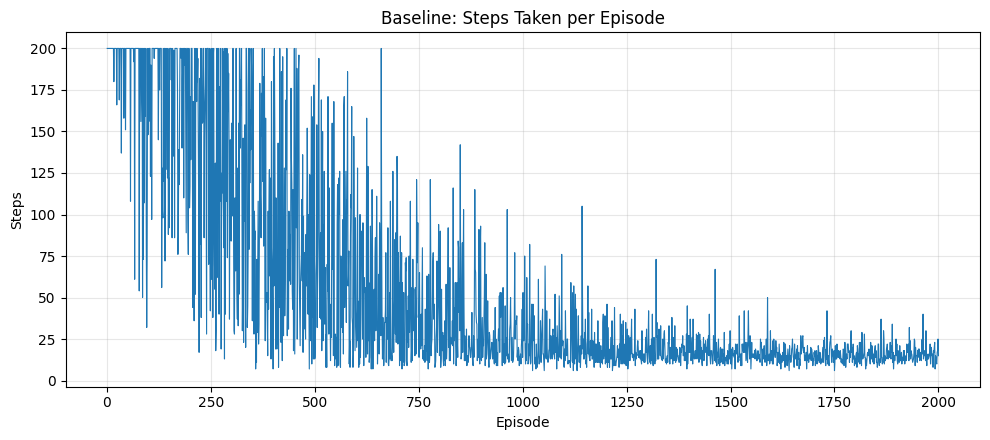

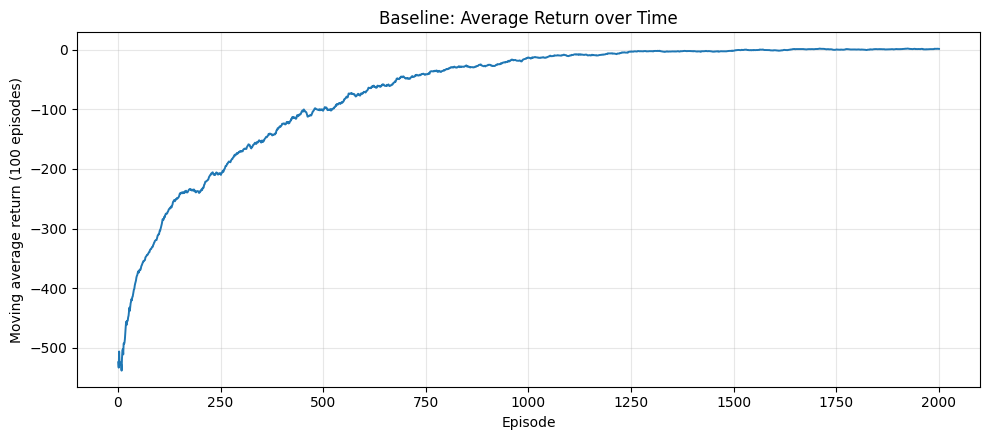

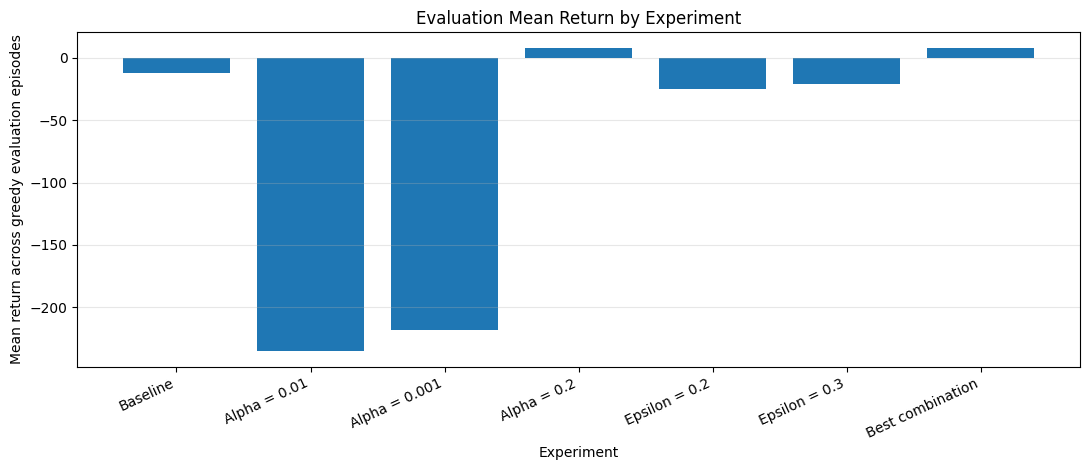

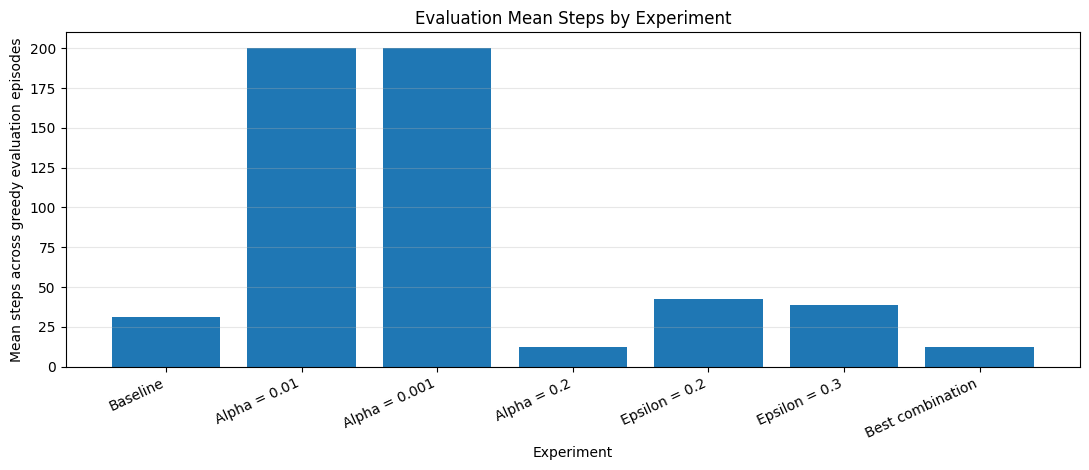

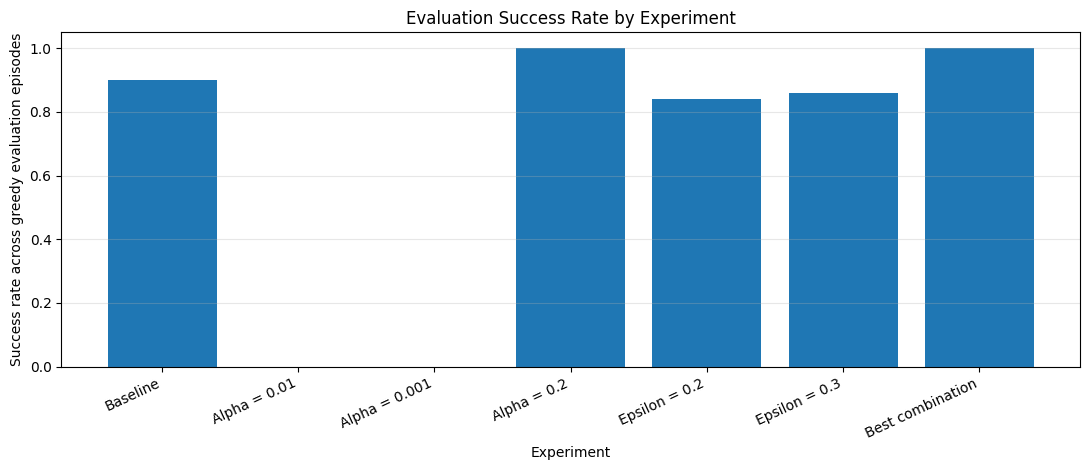

Required experiments complete.
Selected best combination from measured results: {'alpha': 0.2, 'epsilon': 0.1, 'gamma': 0.9}
Experiment summary saved to: /mnt/data/CSCN8020_Assignment2_Final/results/experiment_summary.csv


In [4]:
experiment_logger = ExperimentLogger(LOG_DIR / "qlearning_experiments.log")
trainer = QLearningTrainer(environment_manager, experiment_logger)
plot_manager = PlotManager(ASSETS_DIR)
experiment_runner = ExperimentRunner(trainer, plot_manager)

comparison_table, selected_combination, comparison_with_best = experiment_runner.run_required_experiments()

results_path = RESULTS_DIR / "experiment_summary.csv"
comparison_with_best.to_csv(results_path, index=False)

print("Required experiments complete.")
print("Selected best combination from measured results:", selected_combination)
print(f"Experiment summary saved to: {results_path}")

## 7. Training metrics and interpretation

The table below contains the required total episode count, return-related metrics, step metrics, and greedy evaluation results for each experiment. The evaluation is intentionally greedy (`epsilon = 0`) so the measured result reflects the policy learned by the Q-table rather than random exploration during testing.

In [5]:
summary_columns = [
    "experiment",
    "alpha",
    "epsilon",
    "gamma",
    "episodes",
    "training_mean_return_last_window",
    "training_mean_steps_last_window",
    "training_success_rate_last_window",
    "evaluation_mean_return",
    "evaluation_mean_steps",
    "evaluation_success_rate",
]

display(
    comparison_with_best[summary_columns]
    .sort_values("evaluation_mean_return", ascending=False)
    .round(3)
    .reset_index(drop=True)
)

baseline_row = comparison_with_best.loc[comparison_with_best["experiment"] == "Baseline"].iloc[0]
best_row = comparison_with_best.loc[comparison_with_best["experiment"] == "Best combination"].iloc[0]

display(
    Markdown(
        f"""
### Baseline interpretation
The baseline agent trained for **{int(baseline_row['episodes']):,} episodes**. In the final training window, its mean return was **{baseline_row['training_mean_return_last_window']:.2f}** and its mean number of steps was **{baseline_row['training_mean_steps_last_window']:.2f}**. During greedy evaluation, it achieved a mean return of **{baseline_row['evaluation_mean_return']:.2f}**, a mean of **{baseline_row['evaluation_mean_steps']:.2f}** steps, and a success rate of **{baseline_row['evaluation_success_rate']:.1%}**.

### Best-combination interpretation
The best combination selected from the measured single-parameter tests was **alpha = {selected_combination['alpha']:.3f}** and **epsilon = {selected_combination['epsilon']:.3f}**. Its greedy evaluation mean return was **{best_row['evaluation_mean_return']:.2f}** with an evaluation success rate of **{best_row['evaluation_success_rate']:.1%}**. The selection rule prioritized higher evaluation return, then success rate, then fewer steps, so it is based on observed performance rather than guesswork.
"""
    )
)

,experiment,alpha,epsilon,gamma,episodes,training_mean_return_last_window,training_mean_steps_last_window,training_success_rate_last_window,evaluation_mean_return,evaluation_mean_steps,evaluation_success_rate
0,Alpha = 0.2,0.200,0.1,0.9,2000,2.192,14.848,1.000,8.35,12.65,1.00
1,Best combination,0.200,0.1,0.9,2000,2.192,14.848,1.000,8.35,12.65,1.00
2,Baseline,0.100,0.1,0.9,2000,0.474,16.026,1.000,-12.48,31.38,0.90
3,Epsilon = 0.3,0.100,0.3,0.9,2000,-16.556,20.708,1.000,-20.70,38.76,0.86
4,Epsilon = 0.2,0.100,0.2,0.9,2000,-7.450,18.352,1.000,-24.84,42.48,0.84
5,Alpha = 0.001,0.001,0.1,0.9,2000,-254.158,183.088,0.172,-218.00,200.00,0.00
6,Alpha = 0.01,0.010,0.1,0.9,2000,-195.922,151.768,0.582,-235.64,200.00,0.00



### Baseline interpretation
The baseline agent trained for **2,000 episodes**. In the final training window, its mean return was **0.47** and its mean number of steps was **16.03**. During greedy evaluation, it achieved a mean return of **-12.48**, a mean of **31.38** steps, and a success rate of **90.0%**.

### Best-combination interpretation
The best combination selected from the measured single-parameter tests was **alpha = 0.200** and **epsilon = 0.100**. Its greedy evaluation mean return was **8.35** with an evaluation success rate of **100.0%**. The selection rule prioritized higher evaluation return, then success rate, then fewer steps, so it is based on observed performance rather than guesswork.


### What the required plots show

1. **Total reward / return per episode:** early training usually contains large negative returns because the agent takes random movements, spends many steps wandering, and sometimes performs illegal pickup or drop-off actions. Improvement is visible when returns become less negative and later positive.
2. **Steps per episode:** a reducing trend means the agent is finding shorter routes and completing deliveries more efficiently.
3. **Average return over time:** the moving average removes much of the randomness from individual episodes and makes the learning trend easier to interpret.
4. **Experiment comparison plots:** these show whether changes in learning rate or exploration improved the final greedy policy, not just the noisy training path.

## 8. Hyperparameter experiment discussion

The next cell produces a concise evidence-based discussion from the actual outputs. The explanation is linked to the role of each hyperparameter rather than treating the plots as isolated pictures.

In [6]:
alpha_results = comparison_table[comparison_table["experiment"].str.startswith("Alpha") | (comparison_table["experiment"] == "Baseline")].copy()
epsilon_results = comparison_table[comparison_table["experiment"].str.startswith("Epsilon") | (comparison_table["experiment"] == "Baseline")].copy()

best_alpha_candidate = alpha_results.sort_values(
    ["evaluation_mean_return", "evaluation_success_rate", "evaluation_mean_steps"],
    ascending=[False, False, True],
).iloc[0]
best_epsilon_candidate = epsilon_results.sort_values(
    ["evaluation_mean_return", "evaluation_success_rate", "evaluation_mean_steps"],
    ascending=[False, False, True],
).iloc[0]

alpha_table = alpha_results[["experiment", "alpha", "epsilon", "evaluation_mean_return", "evaluation_mean_steps", "evaluation_success_rate"]].round(3)
epsilon_table = epsilon_results[["experiment", "alpha", "epsilon", "evaluation_mean_return", "evaluation_mean_steps", "evaluation_success_rate"]].round(3)

display(Markdown("### Learning-rate experiments"))
display(alpha_table.reset_index(drop=True))
display(Markdown("### Exploration-factor experiments"))
display(epsilon_table.reset_index(drop=True))

display(
    Markdown(
        f"""
### Interpretation of alpha
The strongest tested learning-rate setting in this run was **alpha = {best_alpha_candidate['alpha']:.3f}**. The learning rate controls how much each new TD error changes the Q-table. A very small alpha can make learning slow because useful rewards propagate through the Q-table only gradually. A larger alpha can learn faster, although an excessively large value can make estimates less stable in noisier environments.

### Interpretation of epsilon
The strongest tested exploration setting in this run was **epsilon = {best_epsilon_candidate['epsilon']:.3f}**. Epsilon controls how often the agent deliberately explores rather than following its current best-known action. More exploration can expose useful routes and reduce early overcommitment to bad actions, but too much exploration can reduce short-term efficiency because random actions still include wasted movement and illegal actions.

### Why the final pair was selected
The final experiment combines the best independently observed alpha and epsilon values: **alpha = {selected_combination['alpha']:.3f}**, **epsilon = {selected_combination['epsilon']:.3f}**. This follows the assignment instruction to first test alpha and epsilon separately, then choose and re-run a defensible final combination.
"""
    )
)

### Learning-rate experiments

,experiment,alpha,epsilon,evaluation_mean_return,evaluation_mean_steps,evaluation_success_rate
0,Baseline,0.100,0.1,-12.48,31.38,0.9
1,Alpha = 0.01,0.010,0.1,-235.64,200.00,0.0
2,Alpha = 0.001,0.001,0.1,-218.00,200.00,0.0
3,Alpha = 0.2,0.200,0.1,8.35,12.65,1.0


### Exploration-factor experiments

,experiment,alpha,epsilon,evaluation_mean_return,evaluation_mean_steps,evaluation_success_rate
0,Baseline,0.1,0.1,-12.48,31.38,0.90
1,Epsilon = 0.2,0.1,0.2,-24.84,42.48,0.84
2,Epsilon = 0.3,0.1,0.3,-20.70,38.76,0.86



### Interpretation of alpha
The strongest tested learning-rate setting in this run was **alpha = 0.200**. The learning rate controls how much each new TD error changes the Q-table. A very small alpha can make learning slow because useful rewards propagate through the Q-table only gradually. A larger alpha can learn faster, although an excessively large value can make estimates less stable in noisier environments.

### Interpretation of epsilon
The strongest tested exploration setting in this run was **epsilon = 0.100**. Epsilon controls how often the agent deliberately explores rather than following its current best-known action. More exploration can expose useful routes and reduce early overcommitment to bad actions, but too much exploration can reduce short-term efficiency because random actions still include wasted movement and illegal actions.

### Why the final pair was selected
The final experiment combines the best independently observed alpha and epsilon values: **alpha = 0.200**, **epsilon = 0.100**. This follows the assignment instruction to first test alpha and epsilon separately, then choose and re-run a defensible final combination.


## 9. Five required talking points

Each talking point below addresses: (1) a key reinforcement learning feature, (2) an implementation or testing challenge, and (3) why this is reinforcement learning instead of another type of machine learning. Each point also explicitly maps the notebook to the Q-learning pseudocode.

### Talking point 1: State-action values and tabular learning

**RL feature:** The Q-table stores one learned value for every state-action pair, `Q[s, a]`. In Taxi-v3, this creates a 500 × 6 table. The `QLearningAgent` initializes that table with zeros, which maps directly to the pseudocode step “initialize `Q(s, a)` arbitrarily.”

**Challenge:** At the beginning, all actions have equal values. The agent therefore has no meaningful preference and receives many negative rewards before good routes are discovered.

**Why this is RL:** There is no labelled dataset containing the best Taxi action for each state. The values are learned from interaction: observe state `S`, take action `A`, receive reward `R`, observe next state `S'`, and update `Q(S,A)`.

### Talking point 2: Exploration versus exploitation

**RL feature:** `QLearningAgent.select_action()` implements epsilon-greedy selection. With probability epsilon, the agent explores a random action; otherwise, it exploits the largest current Q-value. This maps to “choose action `A` from `S` using a policy derived from Q.”

**Challenge:** Exploration can produce illegal pickup and drop-off attempts, which receive -10. However, removing exploration too early can trap the agent in a poor policy because it never tries alternative routes.

**Why this is RL:** The action policy changes as rewards reshape the Q-table. This is different from supervised learning, where a model would be trained from correct action labels already provided by a teacher.

### Talking point 3: Temporal-difference update and bootstrapping

**RL feature:** `QLearningAgent.update()` applies `Q(S,A) ← Q(S,A) + alpha[R + gamma max_a Q(S',a) - Q(S,A)]`. It uses the current reward and the estimated best value of the next state. This maps directly to the pseudocode step “update Q using R and max Q(S',a).”

**Challenge:** It is important not to bootstrap beyond the end of an episode. The code sets the future term to zero when the episode terminates or reaches the time limit.

**Why this is RL:** The target is generated from observed consequences and the agent's own learned value estimates, not from a fixed labelled answer. This is temporal-difference reinforcement learning.

### Talking point 4: Rewards drive policy improvement

**RL feature:** The Taxi reward structure makes good behaviour measurable: +20 for correct delivery, -1 for each step, and -10 for illegal pickup or drop-off. Repeating updates causes actions leading toward successful delivery to gain higher Q-values.

**Challenge:** A high delivery reward alone would not be enough if each extra movement had no cost. The -1 step reward is important because it distinguishes a short delivery route from a long wandering route.

**Why this is RL:** The agent improves its policy through trial, reward feedback, and value updates. It is not clustering states or predicting a static target; it is making sequential decisions where one action changes the next state.

### Talking point 5: Off-policy learning and greedy evaluation

**RL feature:** Training uses epsilon-greedy behaviour, but the update target uses `max_a Q(S',a)`. This means the agent can learn toward a greedy target policy even while it sometimes behaves randomly. That is the off-policy aspect of Q-learning.

**Challenge:** Training returns can remain noisy because epsilon deliberately injects random actions. Therefore, the notebook separately evaluates the learned policy with `explore=False` so final performance is not confused with intentional exploration noise.

**Why this is RL:** The agent learns by continuously interacting with the environment over episodes until the state is terminal. The objective is to maximize long-term cumulative reward, which is the core reinforcement learning objective.

## 10. Connection to Monte Carlo variance

Monte Carlo methods estimate values using full returns from completed episodes. In Taxi, a long and highly exploratory episode can create a very negative return, so the sample return can vary substantially between episodes.

Q-learning uses a one-step TD target instead:

\[
R + \gamma \max_a Q(S',a)
\]

This still has uncertainty, but it does not wait for the full episode return before updating. The next-state Q estimate acts as a bootstrap target, so reward information can propagate earlier and the update is usually less sensitive to a single unusually long episode. This is the practical connection between the Week 5 MC variance activity and the present Q-learning assignment.

## 11. Final conclusion

This project implemented a complete tabular Q-learning workflow for Taxi-v3. The agent represented the 500-state, 6-action problem with a Q-table; explored using epsilon-greedy behaviour; improved its policy through TD updates; and was evaluated using a greedy policy. The controlled alpha and epsilon experiments show that hyperparameters materially affect learning speed, stability, and final policy quality. The final best-combination run was selected from measured results rather than from an unsupported assumption.

The notebook also demonstrates why this is reinforcement learning: the agent learns from interaction, sequential state transitions, rewards, exploration, and long-term value estimates rather than from pre-labelled examples.

## 11.1 Delivered evidence

The repository includes the executed notebook, the generated plot images in `assets/plots/`, the experiment-level log in `logs/qlearning_experiments.log`, and the compact experiment table in `results/experiment_summary.csv`. Together, these files make the training process, comparisons, and reported conclusions easy to inspect without needing to rerun the notebook first.


## 12. Reproducibility and AI-use acknowledgement

### Reproducibility
Run this notebook from top to bottom after installing the packages listed in `requirements.txt`. The notebook creates its required plots in `assets/plots/` and writes execution details to `logs/qlearning_experiments.log`.

### AI-use acknowledgement
AI tools were used as learning and development support for planning, code review, documentation structure, and explanation refinement. The submitted work was verified by running the notebook, checking the Q-learning update logic, reviewing the generated metrics, and ensuring that the final explanations match the implementation and observed results.

### References
- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
- Gymnasium documentation: Taxi environment.
- CSCN8020 course resources: TD learning and exploration strategy examples.